# CAPTCHA Character Classifier Model Test + Evaluation Metrics
This notebook loads the character classifier model (as defined in model.py) and evaluates all CAPTCHAs in the test set.    
Then, generates some metrics (Full CAPTCHA and Per-character) for the model.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F
import cv2
import os
from tqdm import tqdm

from torchvision.transforms import v2

from utils import preprocessing_remove_lines, is_char_correct_with_allowance, split_into_char_images

In [2]:
source_folder = "test/"
captcha_files = [f for f in os.listdir(source_folder) if f.lower().endswith(".png")]
if not captcha_files:
    raise FileNotFoundError(f"No Captcha files found in {source_folder}")

# Setup GPU

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


# Setup CNN-Attention Transformer Model

In [4]:
char_classes = {
    "0": 0,
    "1": 1,
    "2": 2,
    "3": 3,
    "4": 4,
    "5": 5,
    "6": 6,
    "7": 7,
    "8": 8,
    "9": 9,
    "a": 10,
    "b": 11,
    "c": 12,
    "d": 13,
    "e": 14,
    "f": 15,
    "g": 16,
    "h": 17,
    "i": 18,
    "j": 19,
    "k": 20,
    "l": 21,
    "m": 22,
    "n": 23,
    "o": 24,
    "p": 25,
    "q": 26,
    "r": 27,
    "s": 28,
    "t": 29,
    "u": 30,
    "v": 31,
    "w": 32,
    "x": 33,
    "y": 34,
    "z": 35,
}
num_classes = len(char_classes)
print(num_classes)

36


In [5]:
from model import ImageSequenceClassifier

net = torch.load("captcha_char_classifier_model.pth", map_location=device, weights_only=False)
net.to(device)
net.eval()

def count_params(net, trainable=False):
    if trainable:
        count = sum(p.numel() for p in net.parameters() if p.requires_grad)
    else:
        count = sum(p.numel() for p in net.parameters())
    return count

print(F'Network has {count_params(net, trainable=False)} parameters in total')
print(F'Network has {count_params(net, trainable=True)} trainable parameters in total')

Network has 2165236 parameters in total
Network has 2165236 trainable parameters in total


# Eval Single Image

In [6]:
import torch
import cv2
from torchvision import transforms

def predict_captcha(model, img, char_classes, device='cuda'):
    """
    Predict the captcha string for a single captcha image.
    
    Args:
        model: trained ImageSequenceClassifier model
        image_path: path to captcha image
        char_classes: dict mapping char -> index
        device: 'cuda' or 'cpu'
    
    Returns:
        predicted string
    """
    model.eval()
    
    # Read image
    if img is None:
        raise FileNotFoundError(f"Cannot read image")
    
    # Split into character images
    char_imgs = split_into_char_images(img)  # your existing function
    
    # Transform character images
    transform = transforms.Compose([
        transforms.ToPILImage(),
        transforms.ToTensor()  # output shape: [1, H, W]
    ])
    char_tensors = [transform(cv2.resize(ch, (42, 42))) for ch in char_imgs]
    
    # Stack into [N, C, H, W]
    x = torch.stack(char_tensors).unsqueeze(0).to(device)  # [1, N, C, H, W]
    
    # Create mask
    mask = torch.ones(1, x.size(1), dtype=torch.bool).to(device)
    
    # Forward pass
    with torch.no_grad():
        logits = model(x, mask)       # [1, N, num_classes]
        preds = logits.argmax(dim=-1) # [1, N]
    
    # Map back to characters
    idx_to_char = {v: k for k, v in char_classes.items()}
    pred_chars = [idx_to_char[i.item()] for i in preds[0, :mask.sum()]]
    
    return pred_chars

In [16]:
import matplotlib.pyplot as plt
import torch

def visualize_stn(net, char_imgs, device):
    # Visualize how the Spatial Transformer Network (STN) modifies each character image.
    net.eval()
    net.to(device)

    # Ensure all are tensors on same device
    char_tensors = [torch.from_numpy(ci).unsqueeze(0).float() / 255.0 for ci in char_imgs]
    X = torch.stack(char_tensors).unsqueeze(0).to(device)  # [1, N, C, H, W]

    # For visualization
    originals = [ci.squeeze().cpu().numpy() for ci in char_tensors]

    # Pass through STN only to get transformed images
    with torch.no_grad():
        B, N, C, H, W = X.shape
        X_flat = X.reshape(B * N, C, H, W)
        transformed = net.featuriser.stn(X_flat)  # apply STN
        transformed = transformed.cpu().numpy()

    transformed_imgs = [t[0] for t in transformed] 

    # Plot results
    num_chars = len(originals)
    plt.figure(figsize=(2 * num_chars, 4))

    for i in range(num_chars):
        # Original
        plt.subplot(2, num_chars, i + 1)
        plt.imshow(originals[i], cmap='gray')
        plt.title(f"Original {i}")
        plt.axis('off')

        # STN output
        plt.subplot(2, num_chars, num_chars + i + 1)
        plt.imshow(transformed_imgs[i], cmap='gray')
        plt.title(f"STN Out {i}")
        plt.axis('off')

    plt.suptitle("Spatial Transformer Effect per Character")
    plt.tight_layout()
    plt.show()

Predicted captcha: ['o', 'a', '7', 's', 'h', '2', 'w', 'p']


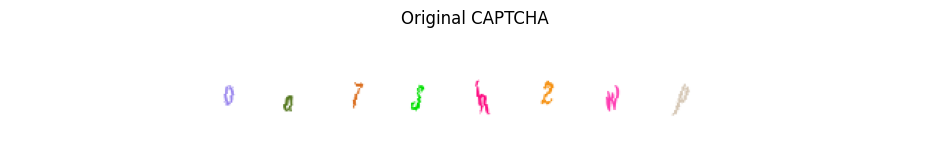

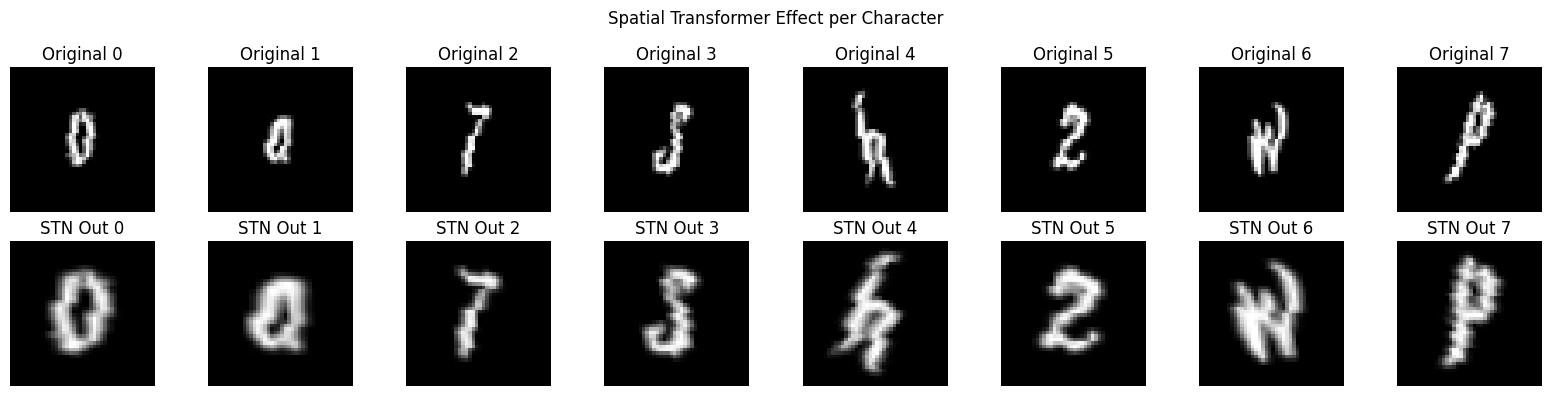

In [19]:
test_captcha_path = "test/0a7sh2wp-0.png"
test_captcha_img = cv2.imread(test_captcha_path)
predicted = predict_captcha(net, test_captcha_img, char_classes, device=device)
print("Predicted captcha:", predicted)

# Show the captcha
plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(test_captcha_img, cv2.COLOR_BGR2RGB))  # Convert BGR → RGB
plt.title("Original CAPTCHA")
plt.axis('off')
plt.show()

test_char_images = split_into_char_images(test_captcha_img)

# Show the STN transformed images
visualize_stn(net, test_char_images, device)

# Eval on whole test set

In [21]:
test_folder = "test/"
captcha_files = [f for f in os.listdir(test_folder) if f.lower().endswith(".png")]
if not captcha_files:
    raise FileNotFoundError(f"No Captcha files found in {test_folder}")

images_count = 0
wrong_char_num_count = 0
correct = 0
correct_with_allowance = 0

character_count = 0
correct_char_count = 0
correct_char_count_with_allowance = 0

# Setup confusion matrix calculation
idx_to_char = {v: k for k, v in char_classes.items()}
confusion = np.zeros((len(char_classes), len(char_classes)), dtype=int) # rows = ground truth, cols = predicted

for (root,dirs,files) in os.walk(test_folder,topdown=True):
    for file in tqdm(files, desc="Loading images"):
        if file.endswith('.png'):
            if file[1] == "_":
                os.remove(os.path.join(root, file))
                continue

            images_count += 1

            correct_char_array = list(file.split("-")[0])
            character_count += len(correct_char_array)
            img_path = os.path.join(root, file)
            img = cv2.imread(img_path)

            predicted_char_array = predict_captcha(net, img, char_classes, device=device)

            # add to confusion matrix
            for c1, c2 in zip(correct_char_array, predicted_char_array):
                gt_idx = char_classes[c1]
                pred_idx = char_classes[c2]
                confusion[gt_idx, pred_idx] += 1

            correct_char_count += sum(c1 == c2 for c1, c2 in zip(correct_char_array, predicted_char_array))
            correct_char_count_with_allowance += sum(is_char_correct_with_allowance(c1, c2) for c1, c2 in zip(correct_char_array, predicted_char_array))

            # Wrong number of characters
            if len(correct_char_array) != len(predicted_char_array):
                wrong_char_num_count += 1
                continue

            # All correct
            if all(c1 == c2 for c1, c2 in zip(correct_char_array, predicted_char_array)):
                correct += 1
                correct_with_allowance += 1
                continue

            # ALl correct only with allowance
            if all(is_char_correct_with_allowance(c1, c2) for c1, c2 in zip(correct_char_array, predicted_char_array)):
                correct_with_allowance += 1
                continue

print(f'Test folder: {test_folder}')
print("")
print(f'Captcha count: {images_count}')
print(f'Wrong number of characters: {wrong_char_num_count} ({(wrong_char_num_count / images_count * 100):.2f}%)')
print(f'Correct: {correct} ({(correct / images_count * 100):.2f}%)')
print(f'Correct with allowance: {correct_with_allowance} ({(correct_with_allowance / images_count * 100):.2f}%)')
print("")
print(f'Total character count: {character_count}')
print(f'Correct characters: {correct_char_count} ({(correct_char_count / character_count * 100):.2f}%)')
print(f'Correct characters with allowance: {correct_char_count_with_allowance} ({(correct_char_count_with_allowance / character_count * 100):.2f}%)')

Loading images: 100%|██████████████████████████████████████████████████████████████| 2001/2001 [01:40<00:00, 19.90it/s]

Test folder: test/

Captcha count: 2000
Wrong number of characters: 93 (4.65%)
Correct: 1532 (76.60%)
Correct with allowance: 1770 (88.50%)

Total character count: 12010
Correct characters: 11121 (92.60%)
Correct characters with allowance: 11438 (95.24%)


# Print Characters Confusion Matrix
Confusion matrix is also used to calculate Precision, Recall, F1 Score.

In [36]:
# Print matrix in readable form
print("Confusion Matrix (rows = ground truth, cols = prediction):")

header = "     " + " ".join(f"{c:>3}" for c in idx_to_char.values())
print(header)

for i, row_char in idx_to_char.items():
    row_values = " ".join(f"{v:>3}" for v in confusion[i])
    print(f"{row_char:>3}  {row_values}")

Confusion Matrix (rows = ground truth, cols = prediction):
       0   1   2   3   4   5   6   7   8   9   a   b   c   d   e   f   g   h   i   j   k   l   m   n   o   p   q   r   s   t   u   v   w   x   y   z
  0  253   2   0   0   0   0   2   0   0   1   0   1   1   2   0   0   0   0   1   1   1   1   0   0  71   0   0   0   0   0   0   0   1   0   0   0
  1    2 261   0   0   0   0   0   4   0   1   0   0   1   0   1   0   0   1  22   0   0  15   3   0   0   0   1   0   0   0   0   0   1   0   0   1
  2    1   1 293   0   0   0   1   0   0   2   1   1   1   1   1   0   0   0   0   0   0   2   2   0   0   0   1   0   1   1   1   0   1   0   0   6
  3    2   0   0 316   0   0   0   1   0   3   0   2   0   0   0   0   1   1   0   0   0   0   4   1   1   0   0   0   0   0   0   1   2   3   0   0
  4    4   0   1   0 302   0   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0   0   0   0   0   0   2   0   1   0   1   1   1   0
  5    0   0   0   0   0 294   3   0   1   1   

### Heatmap Diagram (Normalized per ground truth character)

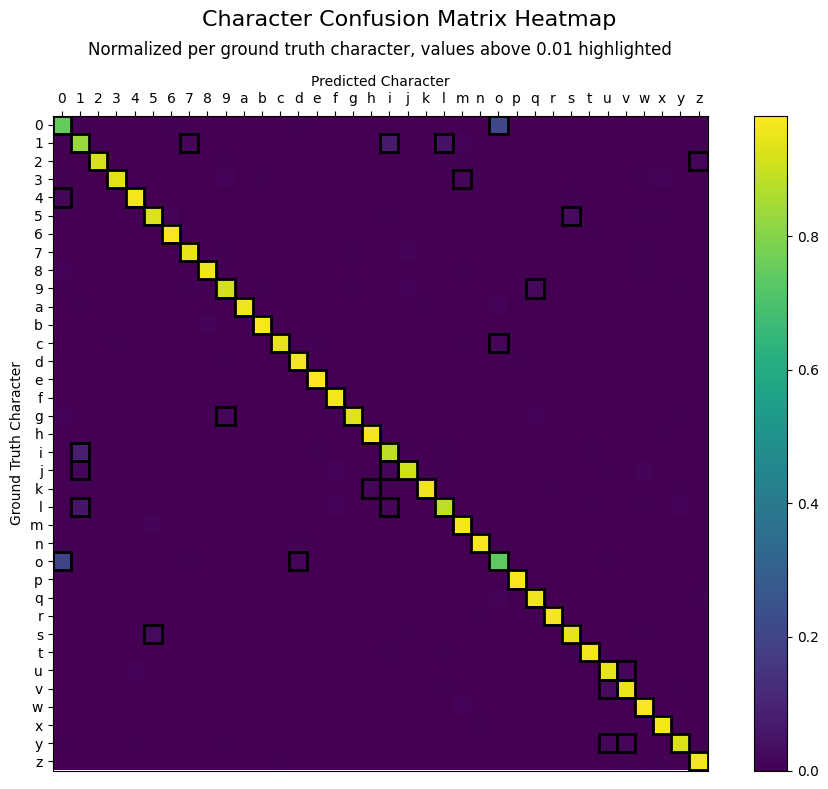

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as patches

# Create list of chars in index order
chars = [idx_to_char[i] for i in range(len(idx_to_char))]

norm_conf = confusion / confusion.sum(axis=1, keepdims=True) # Normalize values per ground truth character

plt.figure(figsize=(10, 8))
plt.imshow(norm_conf, interpolation='nearest')
plt.suptitle("Character Confusion Matrix Heatmap", fontsize=16, y=0.98)
plt.title("Normalized per ground truth character, values above 0.01 highlighted", y=1.08)
plt.xlabel("Predicted Character")
plt.ylabel("Ground Truth Character")

ax = plt.gca()
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')

plt.xticks(np.arange(len(chars)), chars)
plt.yticks(np.arange(len(chars)), chars)

# Draw rectangle around cells above threshold
threshold = 0.01
rows, cols = np.where(norm_conf > threshold)
for r, c in zip(rows, cols):
    rect = patches.Rectangle(
        (c - 0.5, r - 0.5),       
        1, 1,                      
        fill=False,
        linewidth=2,
        edgecolor='black'          
    )
    ax.add_patch(rect)


plt.colorbar()
plt.tight_layout()
plt.show()

# Calculate Precision, Recall, F1 Score

In [38]:
precision_list = []
recall_list = []
f1_list = []

for i in range(num_classes):
    TP = confusion[i, i]
    FP = confusion[:, i].sum() - TP
    FN = confusion[i, :].sum() - TP

    precision = TP / (TP + FP + 1e-12) # small value avoids zero division
    recall = TP / (TP + FN + 1e-12)
    f1 = 2 * precision * recall / (precision + recall + 1e-12)

    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)

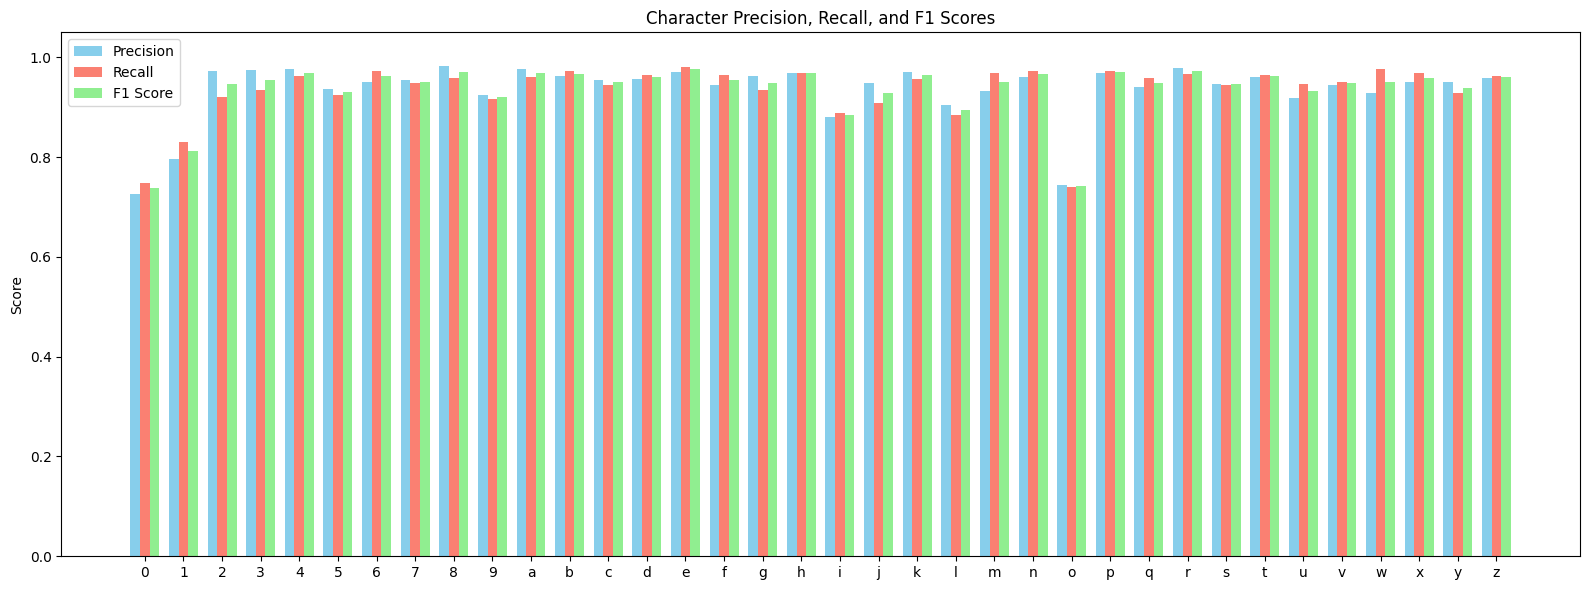

In [39]:
chars = [idx_to_char[i] for i in range(len(char_classes))]
x = np.arange(len(chars))  # positions for each character

width = 0.25  # width of the bars

plt.figure(figsize=(16, 6))

plt.bar(x - width, precision_list, width, label='Precision', color='skyblue')
plt.bar(x, recall_list, width, label='Recall', color='salmon')
plt.bar(x + width, f1_list, width, label='F1 Score', color='lightgreen')

plt.xticks(x, chars)
plt.ylabel('Score')
plt.title('Character Precision, Recall, and F1 Scores')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
# Best F1
best_f1 = max(f1_list)
best_idx = f1_list.index(best_f1)
best_char = chars[best_idx]

# Worst F1
worst_f1 = min(f1_list)
worst_idx = f1_list.index(worst_f1)
worst_char = chars[worst_idx]

print(f"Best F1: Character = '{best_char}', F1 score = {best_f1:.4f}")
print(f"Worst F1: Character = '{worst_char}', F1 score = {worst_f1:.4f}")

Best F1: Character = 'e', F1 score = 0.9761
Worst F1: Character = '0', F1 score = 0.7376


### Calculate Macro Statistics

In [41]:
macro_precision = sum(precision_list) / len(precision_list)
macro_recall    = sum(recall_list) / len(recall_list)
macro_f1        = sum(f1_list) / len(f1_list)

print(f"Macro Precision = {macro_precision:.4f}")
print(f"Macro Recall    = {macro_recall:.4f}")
print(f"Macro F1 Score  = {macro_f1:.4f}")

Macro Precision = 0.9355
Macro Recall    = 0.9350
Macro F1 Score  = 0.9351
